In [ ]:
# mount drive

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import joblib


In [ ]:
# load dataset

df = pd.read_csv('/content/drive/MyDrive/cc_fraud_detection/data/creditcard.csv')

In [ ]:
# check shape (rows and columns) and classes (legit vs fraud)

print(df.shape)
print(df['Class'].value_counts())
df.head()

(284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
# check if any column has missing values

df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


No missing values; cleaning not needed.

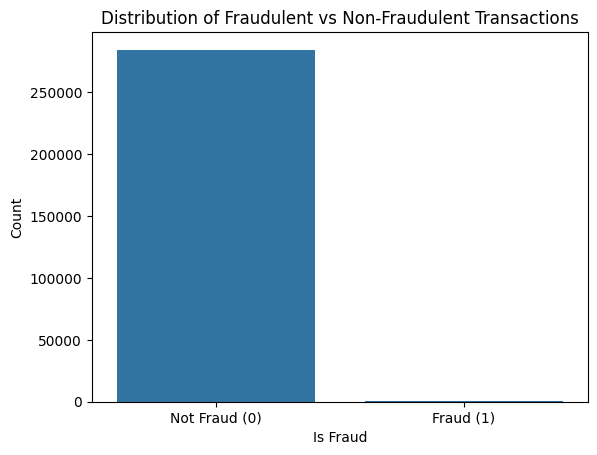

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [ ]:
# plot the class distribution

sns.countplot(x='Class', data=df)
plt.title('Distribution of Fraudulent vs Non-Fraudulent Transactions')
plt.xlabel('Is Fraud')
plt.ylabel('Count')
plt.xticks([0, 1], ['Not Fraud (0)', 'Fraud (1)'])
plt.show()

# print percentage distribution

fraud_rate = df['Class'].value_counts(normalize=True) * 100
print(fraud_rate)


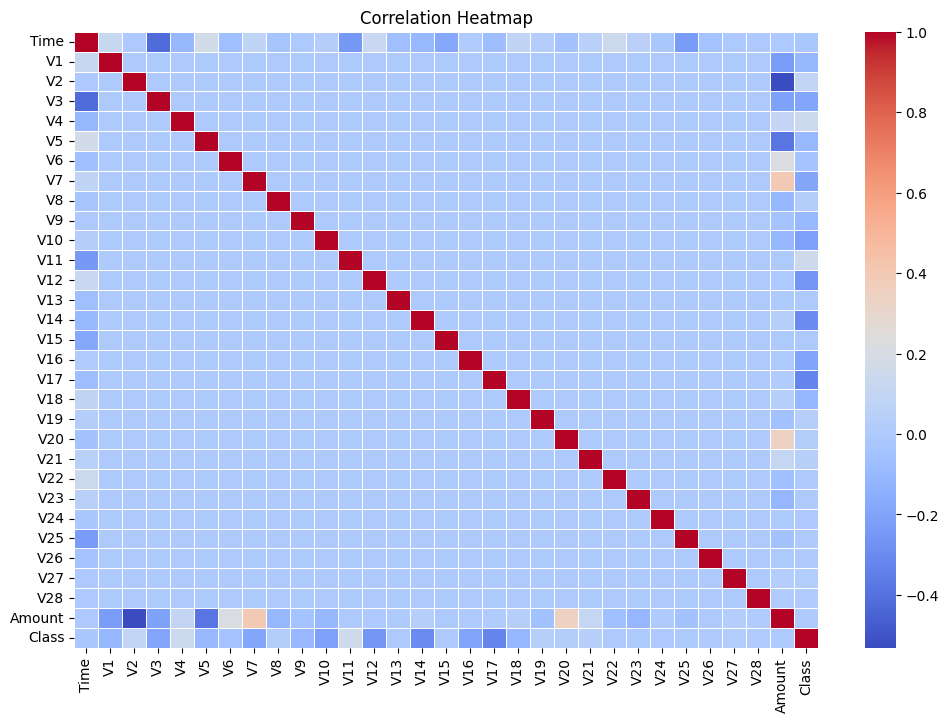

In [ ]:
# plot correlation heatmap

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


A correlation heatmap was plotted to analyze multicollinearity.
Since the majority of features are PCA-transformed, the correlation matrix shows almost no highly correlated feature pairs.
Therefore, no features were removed.

In [45]:
# (preprocessing) separate features and targets and scale amount and time

X = df.drop(columns=['Class']) # inputs/features
y = df['Class'] # output/label

scaler = StandardScaler()
X[['Amount','Time']] = scaler.fit_transform(X[['Amount','Time']])


In [ ]:
# split the data into training and testing sets.
# stratified split to preserve original class distrubution so both train and test sets has same ratio of legit vs fraud transactions.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, "Test:", X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Train: (227845, 30) Test: (56962, 30)
Class
0    0.998271
1    0.001729
Name: proportion, dtype: float64
Class
0    0.99828
1    0.00172
Name: proportion, dtype: float64


In [ ]:
# handle imbalance with SMOTE
# SMOTE creates new synthetic fraud transactions rows to balance the training data

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print("After SMOTE class counts:\n", y_train_res.value_counts())

After SMOTE class counts:
 Class
0    227451
1    227451
Name: count, dtype: int64


In [ ]:
# using Random Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train_res, y_train_res)


RandomForestClassifier(max_depth=10, n_jobs=-1, random_state=42)

In [46]:
# evaluate

def evaluate(model, X_test, y_test, name):
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)

    print(f"--- {name} ---")
    print(classification_report(y_test, y_pred, digits=4))

    roc = roc_auc_score(y_test, y_proba)
    print("ROC AUC:", round(roc, 4))

    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(rec, prec)
    print("PR AUC:", round(pr_auc, 4))

    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
    return y_proba

proba_rf = evaluate(rf_model, X_test, y_test, "Random Forest (SMOTE)")


--- Random Forest (SMOTE) ---
              precision    recall  f1-score   support

           0     0.9998    0.9980    0.9989     56864
           1     0.4279    0.8776    0.5753        98

    accuracy                         0.9978     56962
   macro avg     0.7138    0.9378    0.7871     56962
weighted avg     0.9988    0.9978    0.9982     56962

ROC AUC: 0.9836
PR AUC: 0.8072
Confusion matrix:
 [[56749   115]
 [   12    86]]


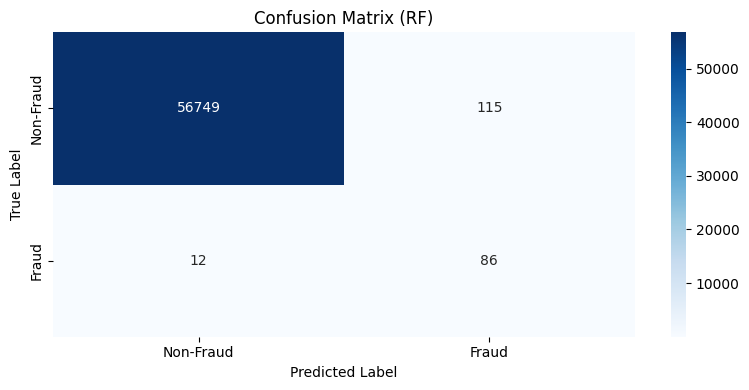

In [47]:
# plot the confusion matrix
# blue intensity = how big the count is

y_pred = (proba_rf >= 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)

labels = ["Non-Fraud", "Fraud"]

plt.figure(figsize=(8, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix (RF)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

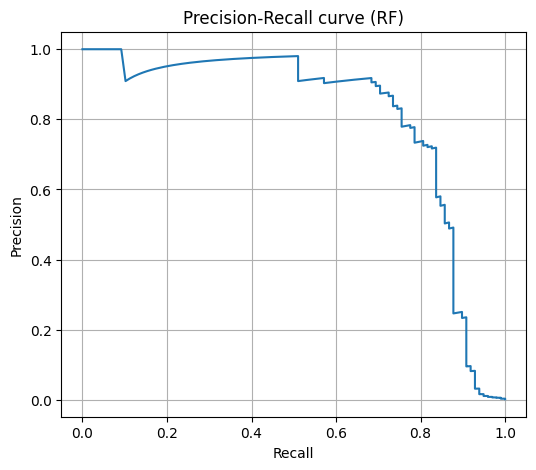

In [ ]:
# PR curve

y_pred = (proba_rf >= 0.5).astype(int)

prec, rec, _ = precision_recall_curve(y_test, proba_rf)
plt.figure(figsize=(6,5))
plt.plot(rec, prec)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve (RF)')
plt.grid(True)
plt.show()


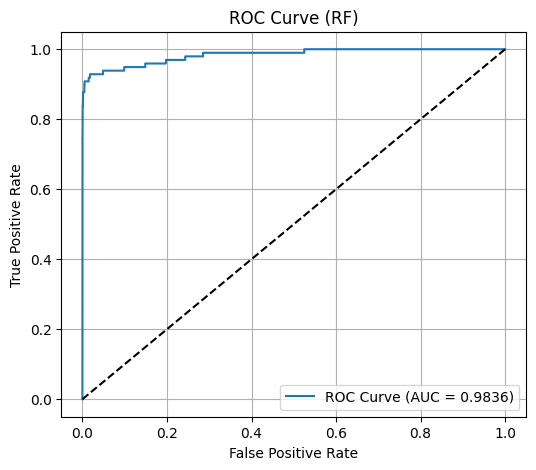

In [ ]:
# ROC curve

from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, proba_rf)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc_score(y_test, proba_rf):.4f})")
plt.plot([0,1], [0,1], 'k--')  # diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (RF)')
plt.legend()
plt.grid(True)
plt.show()


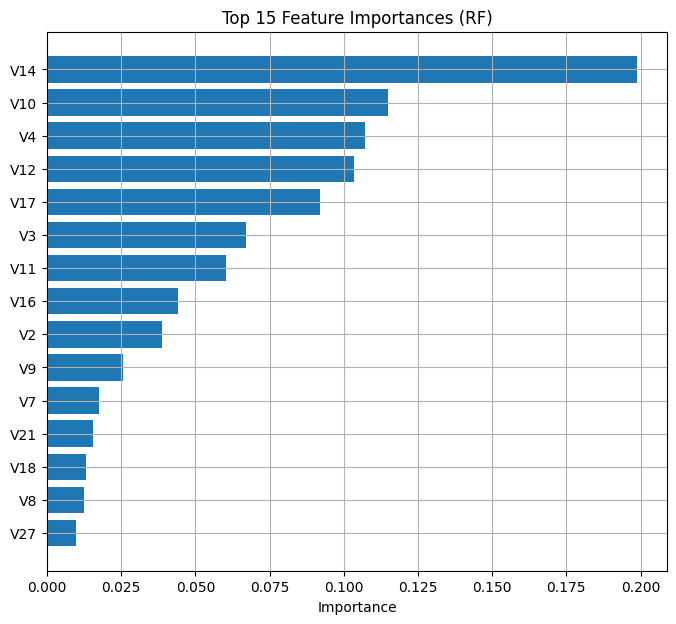

In [ ]:
# feature importance plot

importances = rf_model.feature_importances_
feature_names = X_train.columns

# sort
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8,7))
plt.barh(feature_names[indices][:15], importances[indices][:15])
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances (RF)')
plt.xlabel('Importance')
plt.grid(True)
plt.show()


In [48]:
# threshold tuning
# getting metrics for different thresholds

def print_thresholds(y_test, y_proba, thr_list=[0.2,0.3,0.4,0.5]):
    for thr in thr_list:
        pred = (y_proba >= thr).astype(int)
        print("Threshold:", thr)
        print(classification_report(y_test, pred, digits=4))
        print("Confusion:\n", confusion_matrix(y_test, pred))
        print("-"*30)

print_thresholds(y_test, proba_rf, [0.2, 0.3, 0.4, 0.5])


Threshold: 0.2
              precision    recall  f1-score   support

           0     0.9999    0.9762    0.9879     56864
           1     0.0631    0.9286    0.1181        98

    accuracy                         0.9761     56962
   macro avg     0.5315    0.9524    0.5530     56962
weighted avg     0.9983    0.9761    0.9864     56962

Confusion:
 [[55512  1352]
 [    7    91]]
------------------------------
Threshold: 0.3
              precision    recall  f1-score   support

           0     0.9998    0.9913    0.9956     56864
           1     0.1529    0.9082    0.2618        98

    accuracy                         0.9912     56962
   macro avg     0.5764    0.9497    0.6287     56962
weighted avg     0.9984    0.9912    0.9943     56962

Confusion:
 [[56371   493]
 [    9    89]]
------------------------------
Threshold: 0.4
              precision    recall  f1-score   support

           0     0.9998    0.9960    0.9979     56864
           1     0.2748    0.8776    0.4185 

In [ ]:
# save the model

joblib.dump(rf_model, '/content/drive/MyDrive/cc_fraud_detection/models/rf_model_smote.pkl')
joblib.dump(scaler, '/content/drive/MyDrive/cc_fraud_detection/models/scaler.pkl')
print("saved.")

saved.


In [ ]:
# load the model and scaler

rf_model = joblib.load('/content/drive/MyDrive/cc_fraud_detection/models/rf_model_smote.pkl')
scaler = joblib.load('/content/drive/MyDrive/cc_fraud_detection/models/scaler.pkl')

print("loaded")

loaded


  

---



# **TESTING**

In [ ]:
# positional indices of fraudulent transactions in y_test

fraud_positional_indices = []
for i, label in enumerate(y_test):
    if label == 1:
        fraud_positional_indices.append(i)

print("positional indices of fraudulent transactions in the test set:")
if fraud_positional_indices:
    print(fraud_positional_indices)
    print(f"total fraudulent transactions in test set: {len(fraud_positional_indices)}")
else:
    print("no fraudulent transactions found in the test set.")

positional indices of fraudulent transactions in the test set:
[840, 1146, 3287, 4276, 5077, 5453, 7164, 7299, 7337, 9036, 9156, 9179, 9516, 9730, 9770, 10130, 10623, 12266, 12588, 13968, 15712, 16303, 16715, 17046, 18076, 19638, 20216, 20472, 20687, 20971, 20992, 22956, 23090, 23679, 24570, 24869, 25468, 26685, 26892, 28390, 28867, 29865, 30275, 30513, 30724, 31208, 31297, 31804, 32115, 32200, 33111, 34124, 35880, 37511, 37564, 39206, 39433, 39768, 40860, 41174, 41358, 41517, 42712, 43032, 43261, 43479, 43547, 45600, 46122, 46403, 46497, 46841, 47658, 48945, 48975, 49527, 50025, 50557, 50636, 50678, 50818, 51243, 52728, 52772, 52778, 53376, 53979, 54064, 54191, 54701, 54752, 54894, 54930, 55071, 55247, 56143, 56287, 56421]
total fraudulent transactions in test set: 98


In [ ]:
# test on test data set

# positional index of the row (0-indexed within x_test)
row_index = 5077

sample = X_test.iloc[row_index].copy()
sample_dict = sample.to_dict()

sample_df = pd.DataFrame([sample_dict])
proba = rf_model.predict_proba(sample_df)[:,1][0]
pred = int(proba >= 0.5)
true = y_test.iloc[row_index]

print(f"Positional index: {row_index}")
print("Predicted fraud probability:", proba)
print("Predicted class:", pred)
print("True class: ", true)
print("\n")

if pred == true == 1:
        print("TRUE POSITIVE (Fraud correctly detected)")
elif pred == 1 and true == 0:
        print("FALSE POSITIVE (Legit flagged as fraud)")
elif pred == 0 and true == 1:
        print("FALSE NEGATIVE (Fraud missed)")
else:
        print("TRUE NEGATIVE (Legit correctly passed)")

Positional index: 5077
Predicted fraud probability: 0.9795718231346306
Predicted class: 1
True class:  1


TRUE POSITIVE (Fraud correctly detected)


In [ ]:
# test on new unseen data

new_data = {
    'Time': 400,
    'V1': -3.312226542,
    'V2': 1.951992011,
    'V3': -1.609850732,
    'V4': 6.997905588,
    'V5': -0.522187865,
    'V6': -1.426545319,
    'V7': -2.537387306,
    'V8': 2.391657248,
    'V9': -2.770089277,
    'V10': -3.772272145,
    'V11': 3.202033207,
    'V12': -2.899907388,
    'V13': -0.595221881,
    'V14': -4.289253782,
    'V15': 0.38972412,
    'V16': -1.14074718,
    'V17': -2.830055675,
    'V18': -0.016822468,
    'V19': 0.416955705,
    'V20': 0.126910559,
    'V21': 0.517232371,
    'V22': -0.035049369,
    'V23': -0.465211076,
    'V24': 0.45698199,
    'V25': 0.025519167,
    'V26': 0.167839758,
    'V27': 0.352145003,
    'V28': -0.17875875,
    'Amount': 5000
}

sample_df = pd.DataFrame([new_data])

sample_df[['Amount', 'Time']] = scaler.transform(sample_df[['Amount', 'Time']])

proba = rf_model.predict_proba(sample_df)[0][1]
pred = rf_model.predict(sample_df)[0]

print("Fraud probability:", proba)
print("Predicted class:", pred)


Fraud probability: 0.6419990939874387
Predicted class: 1
